# Analyse sémantique de corpus textuels

<img src="https://liora.io/app/uploads/2023/05/Outils-danalyse-semantique-1080x550-1.jpg" width="600">

### 🎯 Objectifs de la permanence

**Comprendre les enjeux de l'analyse sémantique de corpus textuels et apprendre à mobiliser des outils adaptés à ses besoins**

#

1. Analyse sémantique des mots dans un corpus

2. Topic Modelling : analyse thématique et clustering

## **Introduction**

L'**analyse sémantique** est un sous-domaine du **NLP**, qui vise à capturer du **sens** dans des corpus en langage naturel.

En **Humanités Numériques**, elle peut avoir diverses application et permettre d'**explorer** et d'**analyser quantitativement** de **vastes corpus** de textes historiques, d'archives littéraires, etc., afin d'en extraire des informations sémantiques.

#

**Quelques exemples :**

- Etude diachronique d'un mot ou d'une thématique
- Identification de structures thématiques
- Comparaison de corpus
- Analyse de biais culturels
- etc.

## **1. Analyse sémantique des mots dans un corpus**

L'**analyse sémantique des mots** dans un corpus vise à **relier sémantiquement** les mots entre eux, pour comprendre comment un discours est construit et quelles représentations sont associées à un concept.

Les algorithmes qui permettent d'effectuer ces tâches sont les modèles de **_Word Embeddings_**.

Les deux algorithmes de ce type les plus connus sont :

- **GloVe** : Développé par l'université de Stanford, l'algorithme repose sur le comptage des mots, en exploitant la matrice de cooccurrence des mots dans l'ensemble du corpus.

- **Word2Vec** : Développé par Google en 2013, l'algorithme s'appuie sur l'hypothèse que le sens d'un mot peut être déduit de ses contextes d'apparition, c'est-à-dire des mots qui l'entourent.

Le principe commun à ces deux algorithmes est l'**entraînement** de **modèles statistiques** sur de **grands corpus** pour apprendre les **représentations des mots**.


### **Gensim**

Concrètement, pour utiliser ces modèles de représentations sémantiques, on peut utiliser la librairie Python **Gensim**.

Gensim est une librairie Open Source de NLP, dont le but est de rendre l'analyse sémantique accessible et efficace. Elle permet d'effectuer de nombreuses tâches, notamment sémantiques, telles que :

- la **modélisation de sujets**
- la **similarité sémantique** entre des textes ou des mots
- la **classification de textes**
- la **recherche d'informations**
- etc.

Elle permet notamment de charger des modèles GloVe ou Word2Vec déjà entraînés.

<img src="https://repository-images.githubusercontent.com/1349775/202c4680-8f7c-11e9-91c6-745fdcbeffe8" width="250">

In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 41.8 MB/s eta 0:00:00


#### **GloVe**

In [2]:
import gensim.downloader as api

# Charger un modèle déjà entraîné
glove_model = api.load("glove-wiki-gigaword-50")

[==================================================] 100.0% 66.0/66.0MB downloaded


In [3]:
# Afficher les 5 mots les plus similaires à king dans le corpus d'entraînement
print("Mots les plus similaires à king :")
print(glove_model.most_similar("king", topn=5))

# Afficher l'analogie roi - homme + femme = ?
print("\nking - man + woman = ?")
print(glove_model.most_similar(positive=["king", "woman"], negative=["man"], topn=1))

Mots les plus similaires à king :
[('prince', 0.8236179351806641), ('queen', 0.7839043140411377), ('ii', 0.7746230363845825), ('emperor', 0.7736247777938843), ('son', 0.766719400882721)]

king - man + woman = ?
[('queen', 0.8523604273796082)]


Les vecteurs de mots produits par ce modèle ont 50 dimensions, ce qui rend difficile leur compréhension.

Toutefois, il existe des algorithmes de **réduction de dimensionnalité** pour représenter ces vecteurs sur un **plan** (en 2D donc), ce qui est quand-même bien pratique quand on veut obtenir une visualisation des mots dans un espace réduit.

Parmi eux, **PCA** (_Principal Component Analysis_).

<img src="https://media.licdn.com/dms/image/v2/C4D12AQEtW-q4NcDAWg/article-cover_image-shrink_600_2000/article-cover_image-shrink_600_2000/0/1648787394930?e=2147483647&v=beta&t=rTr9aqhvmc-K-Ix1-d1PiOjvji6sOxAX92ehRKjOEsQ" width="600">

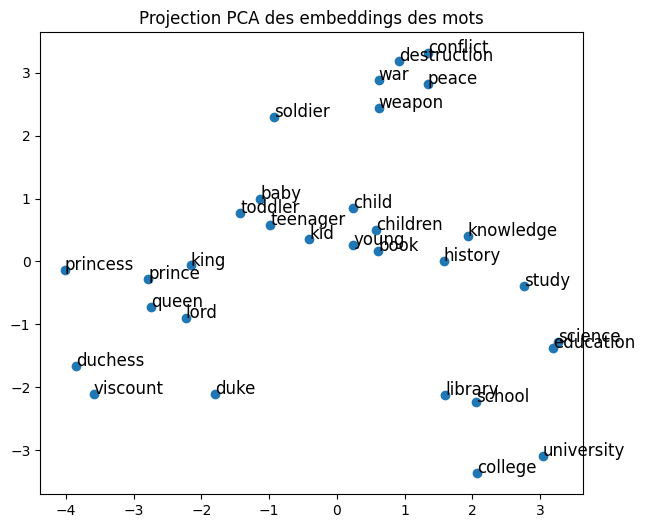

In [4]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Mots qu'on va représenter
mots = [
    "king", "queen", "prince", "princess", "lord", "duke", "duchess", "viscount",
    "baby", "child", "children", "kid", "school", "young", "teenager", "toddler",
    "education", "college", "university", "study", "book", "science", "history", "knowledge", "library",
    "war", "weapon", "soldier", "destruction", "conflict", "peace"
]

# Vectoriser les mots avec notre modèle pré-entraîné
vecteurs = np.array([glove_model[m] for m in mots])

# Réduction de dimensionnalité avec PCA
pca = PCA(n_components=2)
vecteurs_2d = pca.fit_transform(vecteurs)

# Tracé du graphe
plt.figure(figsize=(7, 6))
plt.scatter(vecteurs_2d[:, 0], vecteurs_2d[:, 1])
for i, mot in enumerate(mots):
    plt.annotate(mot, vecteurs_2d[i], fontsize=12)
plt.title("Projection PCA des embeddings des mots")
plt.show()


Les mots qu'on pensait proches sémantiquement se retrouvent dans des zones proches sur le graphique !

#### **Word2Vec**


In [5]:
# Charger un modèle déjà entraîné
w2v_model = api.load("word2vec-google-news-300")

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [6]:
# Afficher les 5 mots les plus similaires à king dans le corpus d'entraînement
print("Mots les plus similaires à king :")
print(w2v_model.most_similar("king", topn=5))

# Afficher l'analogie roi - homme + femme = ?
print("\nking - man + woman = ?")
print(w2v_model.most_similar(positive=["king", "woman"], negative=["man"], topn=1))

Mots les plus similaires à king :
[('kings', 0.7138045430183411), ('queen', 0.6510956883430481), ('monarch', 0.6413194537162781), ('crown_prince', 0.6204220056533813), ('prince', 0.6159993410110474)]

king - man + woman = ?
[('queen', 0.7118193507194519)]


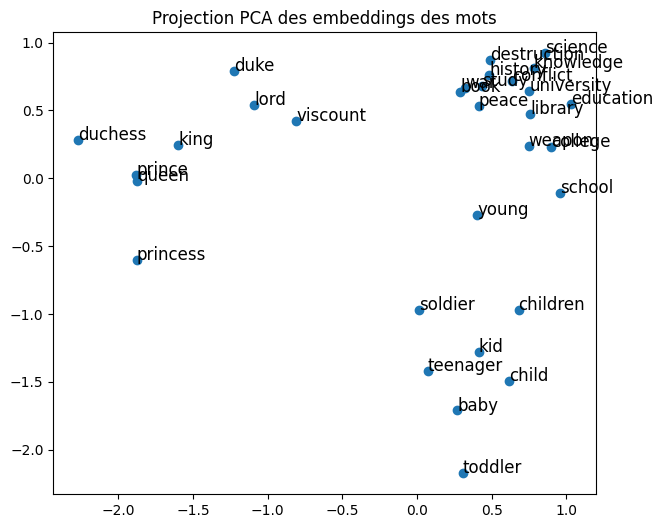

In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Mots qu'on va représenter
mots = [
    "king", "queen", "prince", "princess", "lord", "duke", "duchess", "viscount",
    "baby", "child", "children", "kid", "school", "young", "teenager", "toddler",
    "education", "college", "university", "study", "book", "science", "history", "knowledge", "library",
    "war", "weapon", "soldier", "destruction", "conflict", "peace"
]

# Vectoriser les mots avec notre modèle pré-entraîné
vecteurs = np.array([w2v_model[m] for m in mots])

# Réduction de dimensionnalité avec PCA
pca = PCA(n_components=2)
vecteurs_2d = pca.fit_transform(vecteurs)

# Tracé du graphe
plt.figure(figsize=(7, 6))
plt.scatter(vecteurs_2d[:, 0], vecteurs_2d[:, 1])
for i, mot in enumerate(mots):
    plt.annotate(mot, vecteurs_2d[i], fontsize=12)
plt.title("Projection PCA des embeddings des mots")
plt.show()

Les résultats obtenus varient en fonction du type de modèle utilisé, et de son corpus d'entraînement.

On vient de voir qu'il était possible d'utiliser des algorithmes pour capturer le **_sens_** des mots, ou du moins leur **similarité** entre eux.

Et la bonne nouvelle, c'est que cette technique n'est pas réservée qu'aux mots (_Youpi !_ 🥳). On peut également générer des représentations sémantiques de **phrases**.

## **2. Analyse sémantique des phrases**

Les phrases peuvent elles aussi être représentées par des vecteurs sémantiques, avec des modèles tels que **BERT** ou **GPT**.

Ces _embeddings_, des **_Sentence Embeddings_**, plus larges que ceux des mots offrent de nouvelles applications possibles :

- **Recherche sémantique** (recherche de phrases similaires)
- **Clustering** (regroupement des phrases par signification)
- **Similitude entre phrases** (mesure du degré de similarité entre deux phrases)
- etc.


L'avantage avec des représentations sémantiques est que cela permet de rapprocher des phrases proche d'un point de vue du sens, **même si les mots utilisés sont différents**.

**Exemple :**

> P1 : _Le juge a refusé la plaidoirie de l'avocat._

> P2 : _Le tribunal a rejeté le plaidoiyer de la défense._

> P3 : _Après la plaidoirie, le juge a mangé un sandwich à l'avocat._

> P4 : _L'avocat est très bon pour la santé._

#

➡️ **Représentation classique :** P1 plus proche de P3 que de P2 car plus de mots en commun

➡️ **Représentation sémantique :** P1 plus proche de P2 que de P3 car sens plus proches

In [8]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Modèle multilingue qui fonctionne bien sur le français
model_sentences = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

# Corpus de phrases
sentences = [
    "Le juge a refusé la plaidoirie de l'avocat.",
    "Le tribunal a rejeté le plaidoiyer de la défense.",
    "Après la plaidoirie, le juge a mangé un sandwich à l'avocat.",
    "L'avocat est très bon pour la santé."
]

# Génération des embeddings
embeddings = model_sentences.encode(sentences)

# Dimension des embeddings
print("Dimension des embeddings :", embeddings.shape)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Dimension des embeddings : (4, 384)


In [9]:
# Phrase cible : première phrase
phrase_cible = sentences[0]

# Encodage de la phrase cible
embedding_request = model_sentences.encode([phrase_cible])

# Calcul des scores de similarité avec les embeddings des autres phrases
scores = cosine_similarity(embedding_request, embeddings)[0]

# Exclure la phrase cible
scores[0] = -1

# Extraction de la phrase la plus proche
best_index = scores.argmax()

# Affichage
print(f'Phrase la plus proche de "{phrase_cible}" :')
print(sentences[best_index])

Phrase la plus proche de "Le juge a refusé la plaidoirie de l'avocat." :
Le tribunal a rejeté le plaidoiyer de la défense.


On peut visualiser la **matrice de similarité** des phrases du corpus pour savoir à quel point le modèle estime que les phrases sont proches ou éloignées sémantiquement.

- Une similarité proche de 0 indique qu'il n'y a aucune similarité entre 2 phrases
- Une similarité proche de 1 indique que les 2 phrases sont très proches sémantiquement

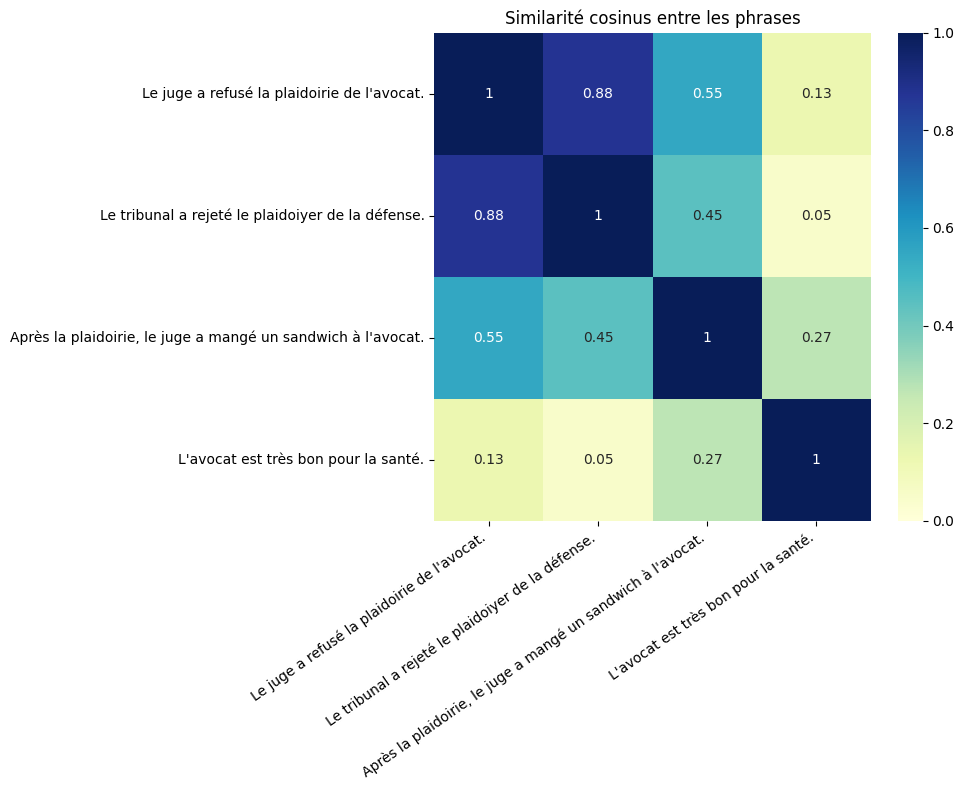

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Matrice de similarité cosinus entre toutes les phrases
similarites = cosine_similarity(embeddings)

# Créer des labels avec le début des phrases
labels = [phrase for phrase in sentences]

# Visualisation
plt.figure(figsize=(10, 8))

sns.heatmap(
    similarites,
    annot=True,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Similarité cosinus entre les phrases")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## **3. Applications**

- **Entraînement d'un modèle de Word Embeddings sur un corpus**
- Topic Modelling : analyse thématique et clustering


### **⚙️ Entraînement d'un modèle de Word Embeddings sur un corpus**

Les modèles de **Word Embeddings**, comme Word2Vec ou GloVe sont généralement entraînés sur de grands corpus pour saisir le sens des mots.

Mais entraîner un modèle de ce type sur son propre corpus présente divers intérêts :

- Capturer la **sémantique propre au corpus** plutôt qu'une sémantique _générale_
- Mener une analyse de l'**évolution temporelle** de l'utilisation d'un mot
- **Comparer** des sous-corpus (auteurs, médias, etc.)
- Détecter des **biais**
- Traiter des **corpus spécialisés**

#### **Outils**

Pour **entraîner un modèle de Word Embeddings** sur un corpus, nous allons utiliser la librairie Python **glovpy**, développée par Stanford, qui permet l'implémentation de l'algorithme GloVe en Python.

Pour la **normalisation** et le **nettoyage** du corpus, nous utiliserons la librairie Python **SpaCy**, conçue pour effectuer diverses tâches de NLP plus ou moins complexes, telles que la tokenisation, la lemmatisation, l'étiquetage morphosyntaxique, la reconnaissance d'entités nommées, etc.

Enfin, pour interroger les **réseaux d'association de mots** dans le modèle généré, nous utiliserons la librairie **embedding-explorer**.

In [11]:
!pip install glovpy                          # Installer GlovPy
!pip install embedding-explorer              # Installer embedding-explorer
!pip install spacy                           # Installer spaCy
!python3 -m spacy download fr_core_news_sm   # Télécharger un modèle dans la langue du corpus (ici français)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 13.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 443.1/443.1 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.8/101.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.7/94.7 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.2/54.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.6/233.6 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━

#### **Exemple d'application n°1 : Corpus de presse 📰**

Jeu de données : _MLSUM French (PARTAGES evaluation mirror)_ [🔗](https://huggingface.co/datasets/zanellac/mlsum-partages)

→ Corpus d'environ 400 000 résumés d'articles du Monde, de 2010 à 2018, rédigés par des journalistes à partir des articles originaux.

<img src="https://www.lde.fr/wp-content/uploads/2024/09/le-monde-logo-redim.png" width="300">




**1. Chargement des données**

In [12]:
from datasets import load_dataset
ds = load_dataset("zanellac/mlsum-partages")

README.md:   0%|          | 0.00/3.08k [00:00<?, ?B/s]

data/train-00000-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  277MB            

data/train-00000-of-00003.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  284MB            

data/train-00001-of-00003.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 41.8MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/392902 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/16059 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/15828 [00:00<?, ? examples/s]

In [13]:
# Afficher le dataset
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'summary', 'topic', 'url', 'title', 'date'],
        num_rows: 392902
    })
    validation: Dataset({
        features: ['text', 'summary', 'topic', 'url', 'title', 'date'],
        num_rows: 16059
    })
    test: Dataset({
        features: ['text', 'summary', 'topic', 'url', 'title', 'date'],
        num_rows: 15828
    })
})

On ne va utiliser que l'ensemble d'évaluation du dataset, et uniquement les résumés.

In [14]:
test = ds["test"]
test

Dataset({
    features: ['text', 'summary', 'topic', 'url', 'title', 'date'],
    num_rows: 15828
})

Et on va le convertir en DataFrame pour faciliter les opérations et les analyses.

In [15]:
test_df = test.to_pandas()
corpus_presse = test_df
corpus_presse

,text,summary,topic,url,title,date
0,Le défenseur de Liverpool Virgil van Dijk célè...,Mohamed Salah et Divock Origi ont permis à Liv...,football,https://www.lemonde.fr/football/article/2019/0...,Liverpool remporte sa sixième Ligue des champi...,01/06/2019
1,"Michel Serres, en mai 2012. MANUEL COHEN Parmi...","Le philosophe, mort samedi à 88 ans, a su fair...",culture,https://www.lemonde.fr/culture/article/2019/06...,"Michel Serres, une forme française d’universalité",01/06/2019
2,"A Vincennes, en septembre 2018. Serge Picard /...","L’auteur des best-sellers « Les Cinq Sens », «...",disparitions,https://www.lemonde.fr/disparitions/article/20...,Le philosophe et académicien Michel Serres est...,01/06/2019
3,Lyon l’a emporté samedi 1er juin contre Montpe...,"Deuxième demi-finale de suite, pour un club se...",sport,https://www.lemonde.fr/sport/article/2019/06/0...,Top 14 : Lyon bat Montpellier et rejoint Clerm...,01/06/2019
4,"L’ambassadeur américain à Berlin, Richard Gren...",Plusieurs de ces manifestants arboraient une k...,international,https://www.lemonde.fr/international/article/2...,"A Berlin, des personnalités politiques dans la...",01/06/2019
...,...,...,...,...,...,...
15823,Tribune. Emmanuel Macron l’a dit : « Je n’ai p...,"Dans une tribune au « Monde », l’économiste Ma...",idees,https://www.lemonde.fr/idees/article/2019/11/1...,« Instaurer un quota d’immigration par métier ...,12/11/2019
15824,"Ricky Strauss, dirigeant de Disney+, le 18 oct...",A la tête de la plate-forme de vidéo à la dema...,m-le-mag,https://www.lemonde.fr/m-le-mag/article/2019/1...,"Qui est vraiment Ricky Strauss, le patron de D...",12/11/2019
15825,La Microcar Dué plus pack design. SIMPOL / MIC...,"Une clientèle rajeunie, une carrosserie qui a ...",m-styles,https://www.lemonde.fr/m-styles/article/2019/1...,La voiturette est à la fête,12/11/2019
15826,Emily Beecham interprète Alice dans « Little J...,La réalisatrice autrichienne Jessica Hausner m...,culture,https://www.lemonde.fr/culture/article/2019/11...,Fleur funeste pour monde flétri dans « Little ...,12/11/2019


**2. Pré-traitement**

In [16]:
import spacy

# Charger le modèle téléchargé
nlp = spacy.load('fr_core_news_sm')

In [18]:
# Normalisation avec spaCy


# Fonction de normalisation
def normalise_sentences(text):
  """Normalise un texte et retourne une liste de phrases tokenisées"""
  doc = nlp(text)                                                                   # Traitement du texte avec spaCy
  sentences = []
  for sent in doc.sents:                                                            # Segmentation en phrases
    tokens = []
    for token in sent:
      if not token.is_stop and not token.is_punct and token.lemma_.strip() != '':   # Supression stopwords et ponctuation
        if token.ent_type_:
          tokens.append(token.text.lower())                                         # Conservation des entités nommées
        else:
          tokens.append(token.lemma_.lower())                                       # Lemmatisation des autres tokens
    if tokens:
      sentences.append(tokens)
  return sentences


# Application au corpus

from tqdm import tqdm

tokenized_summaries = [
    normalise_sentences(summary)
    for summary in tqdm(corpus_presse["summary"], desc="Normalisation")
]

# Corpus GloVe
glove_corpus = [
    [token for sentence in sentences for token in sentence]
    for sentences in tokenized_summaries
]
glove_corpus[:5]

Normalisation: 100%|██████████| 15828/15828 [04:33<00:00, 57.84it/s]


[['mohamed',
  'salah',
  'divock',
  'origi',
  'permettre',
  'liverpool',
  'remporter',
  'trophé',
  'c1',
  'terme',
  'finale',
  'décevant'],
 ['philosophe',
  'mort',
  'samedi',
  '88',
  'an',
  'savoir',
  'faire',
  'vivre',
  'long',
  'tradition',
  'français',
  'allier',
  'charme',
  'plume',
  'travail',
  'heureux',
  'pensée',
  'générosité',
  'cœur'],
 ['auteur',
  'best-seller',
  'sens',
  'petite',
  'poucette',
  'gaucher',
  'boiteux',
  'éteindre',
  'âge',
  '88',
  'an',
  'entourer',
  'famille'],
 ['demi-final',
  'suite',
  'club',
  'remonter',
  'élit',
  '2016',
  'performance',
  'remarquable',
  'ancre',
  'lou',
  'paysage',
  'rugby',
  'français'],
 ['manifestant',
  'arborer',
  'kippa',
  'port',
  'calotte',
  'espace',
  'public',
  'objet',
  'âpre',
  'débat',
  'semaine',
  'allemagne']]

**3. Entraînement d'un modèle de Word Embeddings**

In [ ]:
from glovpy import GloVe

# Entraînement sur le corpus
model = GloVe()
model.train(glove_corpus)

**4. Analyse**

In [ ]:
# Trouver les mots qui apparaissent le plus souvent avec un mot-cible
model.wv.most_similar("climatique")

In [ ]:
# Calculer la priximité entre des mots

# Couple 1
mot_1 = "danger"
mot_2 = "climatique"
similarity = model.wv.similarity(mot_1, mot_2)
print(f"Similarité entre '{mot_1}' et '{mot_2}' : {similarity:.4f}")

# Couple 2
mot_1 = "intelligence"
mot_2 = "artificiel"
similarity = model.wv.similarity(mot_1, mot_2)
print(f"Similarité entre '{mot_1}' et '{mot_2}' : {similarity:.4f}")

# Couple 3
mot_1 = "espagne"
mot_2 = "football"
similarity = model.wv.similarity(mot_1, mot_2)
print(f"Similarité entre '{mot_1}' et '{mot_2}' : {similarity:.4f}")

In [ ]:
from embedding_explorer import show_network_explorer

# Génération d'un réseau sémantique
vocabulary = model.wv.index_to_key
embeddings = model.wv.vectors
show_network_explorer(vocabulary, embeddings=embeddings)

#### **Exemple d'application n°2 : Corpus de romans 📚**

_Les Mystères de Paris_, Eugène Sue (1842-1843)

<img src="https://upload.wikimedia.org/wikipedia/commons/6/60/Jules_Ch%C3%A9ret_-_Les_Myst%C3%A8res_de_Paris.jpg" width="250">


**Les Mystères de Paris** est un roman français publié en feuilleton par Eugène Sue dans le Journal des débats entre juin 1842 et octobre 1843. Il a par la suite été réédité en **4 tomes**. Montrant la misère à Paris et quelques personnages travaillant à rétablir la **justice**, ce roman-fleuve, à mi-chemin entre le **roman social** et le **roman-feuilleton**, inaugure la littérature de masse.

> _Rodolphe, personnage mystérieux au début du roman, s'attelle à rétablir une forme de justice sociale dans le Paris de la première moitié du XIXe siècle. Il croise donc des travailleurs pauvres, aussi bien que des criminels, voulant récompenser les bons et punir les méchants. Les péripéties des héros leur font parcourir Paris et ses environs, décrivant ainsi des lieux types de population : la ferme, l'immeuble du Vieux Paris et les rues._

_(**Source :** [Wikipédia](https://fr.wikipedia.org/wiki/Les_Myst%C3%A8res_de_Paris))_

Les fichiers contenant les 4 tomes au format .TXT sont téléchargeables [ici](https://github.com/amandinejvl/ObTIC/tree/main/perm_embeddings/data/txt). Il vous faudra ensuite les téléverser dans votre drive pour pouvoir les charger dans le notebook.

**1. Chargement des données**

In [ ]:
# Config Collab
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append("/content/drive/MyDrive/Obtic/Permanences/Embeddings") # A adapter selon votre chemin

In [ ]:
# Chemin vers les données (à adapter selon vos données)
data_dir = "/content/drive/MyDrive/Obtic/Permanences/Embeddings/data/txt"

# Fonction de lecture de fichiers texte
def read_text_file(filepath):
  """Lit un fichier texte"""
  with open(filepath, "r", encoding="utf-8") as f:
    texte = f.read()
  return texte

# Chargement des textes
tome_1 = read_text_file(data_dir + "/Eugene_Sue_Les_mysteres_de_Paris_Tome_1.txt")
tome_2 = read_text_file(data_dir + "/Eugene_Sue_Les_mysteres_de_Paris_Tome_2.txt")
tome_3 = read_text_file(data_dir + "/Eugene_Sue_Les_mysteres_de_Paris_Tome_3.txt")
tome_4 = read_text_file(data_dir + "/Eugene_Sue_Les_mysteres_de_Paris_Tome_4.txt")

# Exemple
print(tome_1[14000:15000])

**2. Nettoyage et normalisation des textes**

In [ ]:
# Nettoyage des textes

import re

def clean_text(texte):
  """Nettoie un texte"""

  # Suppression des balises de chapitre
  texte = texte.replace("<NOUVEAU_CHAPITRE>", "")

  # Suppression des notes de bas de page
  texte = re.sub(r"\n\d.+", "", texte)

  # Suppression des sauts de ligne sauf quand la ligne commence par "-"
  texte = re.sub(r"\n(?!–)", "", texte)

  # Suppression des exposants des notes de bas de page
  def delete_nb_in_words(match):
      return match.group(1)
  texte = re.sub(r"([^\W\d_]+)\d+\b", delete_nb_in_words, texte)

  return texte


# Nettoyage
tome_1_clean = clean_text(tome_1)
tome_2_clean = clean_text(tome_2)
tome_3_clean = clean_text(tome_3)
tome_4_clean = clean_text(tome_4)

# Exemple
print(tome_1_clean[12000:15000])

In [ ]:
# Normalisation des textes avec spaCy


# Fonction de normalisation
def normalise_text(text):
  """Normalise un texte et retourne une liste de phrases tokenisées"""
  doc = nlp(text)                                                                   # Traitement du texte avec spaCy
  sentences = []
  for sent in doc.sents:                                                            # Segmentation en phrases
    tokens = []
    for token in sent:
      if not token.is_stop and not token.is_punct and token.lemma_.strip() != '':   # Supression stopwords et ponctuation
        if token.ent_type_:
          tokens.append(token.text.lower())                                         # Conservation des entités nommées
        else:
          tokens.append(token.lemma_.lower())                                       # Lemmatisation des autres tokens
    if tokens:
      sentences.append(tokens)
  return sentences


# Normalisation

print("Normalisation du tome 1...")
tome_1_norm = normalise_text(tome_1_clean)

print("Normalisation du tome 2...")
tome_2_norm = normalise_text(tome_2_clean)

print("Normalisation du tome 3...")
tome_3_norm = normalise_text(tome_3_clean)

print("Normalisation du tome 4...")
tome_4_norm = normalise_text(tome_4_clean)

**3. Entraînement d'un modèle de Word Embeddings**

In [ ]:
from glovpy import GloVe

# Entraînement sur notre corpus (concaténation des tomes)
corpus_litt = tome_1_norm + tome_2_norm + tome_3_norm + tome_4_norm
model = GloVe()
model.train(corpus_litt)

**4. Analyse**

In [ ]:
# Trouver les mots les plus "similaires" (ceux qui apparaissent dans les mêmes contextes)
model.wv.most_similar("justice")

In [ ]:
# Calculer la similarité entre des mots : à quel point des mots apparaissent dans les mêmes contextes ?

# Couple 1
mot_1 = "plaisir"
mot_2 = "campagne"
similarity = model.wv.similarity(mot_1, mot_2)
print(f"Similarité entre '{mot_1}' et '{mot_2}' : {similarity:.4f}")

# Couple 2
mot_1 = "plaisir"
mot_2 = "paris"
similarity = model.wv.similarity(mot_1, mot_2)
print(f"Similarité entre '{mot_1}' et '{mot_2}' : {similarity:.4f}")

# Couple 3
mot_1 = "plaisir"
mot_2 = "table"
similarity = model.wv.similarity(mot_1, mot_2)
print(f"Similarité entre '{mot_1}' et '{mot_2}' : {similarity:.4f}")

In [ ]:
# Calculer la similarité entre des personnages : à quel point des personnages apparaissent dans les mêmes contextes ?

# Couple 1
mot_1 = "rodolphe"     # (héros dont le but est de rétablir la justice)
mot_2 = "chouette"     # (vieille femme borgne aux projets diaboliques)
similarity = model.wv.similarity(mot_1, mot_2)
print(f"Similarité entre '{mot_1}' et '{mot_2}' : {similarity:.4f}")

# Couple 2
mot_1 = "rodolphe"     # (héros dont le but est de rétablir la justice)
mot_2 = "goualeuse"    # (jeune femme persécutée par la Chouette, protégée par Rodolphe)
similarity = model.wv.similarity(mot_1, mot_2)
print(f"Similarité entre '{mot_1}' et '{mot_2}' : {similarity:.4f}")

# Couple 3
mot_1 = "chouette"     # (héros dont le but est de rétablir la justice)
mot_2 = "goualeuse"    # (jeune femme persécutée par la Chouette, protégée par Rodolphe)
similarity = model.wv.similarity(mot_1, mot_2)
print(f"Similarité entre '{mot_1}' et '{mot_2}' : {similarity:.4f}")

In [ ]:
from embedding_explorer import show_network_explorer

# Génération d'un réseau sémantique
vocabulary = model.wv.index_to_key
embeddings = model.wv.vectors
show_network_explorer(vocabulary, embeddings=embeddings)

L'entraînement d'un modèle de Word Embeddings sur son corpus permet d'obtenir des représentations sémantiques des mots dans ce corpus, et ainsi d'étudier les relations entre les mots dans un contexte donné.

## **3. Applications**

- Entraînement d'un modèle de Word Embeddings sur un corpus
- **Topic Modelling : analyse thématique et clustering**

### **🧩 Topic Modelling : analyse thématique et clustering**

La modélisation de sujets ou **Topic Modelling** est une méthode qui vise à identifier les **structures thématiques** dans un texte.

Cette technique repose sur la notion de **champs sémantiques**, qui sont des ensembles de mots liés par un domaine ou une thématique.

Par exemple :

- Hôpital : 'chirurgien', 'scalpel', 'infirmière', 'anesthésie'.
- Restaurant : 'serveur', 'menu', 'assiette', 'chef'.
- Maison : 'porte', 'toit', 'cuisine', 'lit'.

(**Source :** _[Pandore Toolbox](https://obtic-gpu1.mesu.sorbonne-universite.fr/pandore/documentation_preprocessing)_)

Cette technique peut par la suite permettre d'effectuer des regroupements automatiques de sous-corpus (_clustering_).


Le **Topic Modelling** utilise des algorithmes d'**apprentissage non supervisé** comme le **LDA** (_Latent Dirichlet Allocation_) pour induire des groupes de mots associés à partir de textes.

Les champs sémantiques et le Topic Modelling sont extrêmement utiles pour découvrir les **structures thématiques sous-jacentes** dans de grands corpus documentaires.

(**Source :** _[Pandore Toolbox](https://obtic-gpu1.mesu.sorbonne-universite.fr/pandore/documentation_preprocessing)_)

Nous allons ici utiliser **BERTopic**, qui utilise des embeddings pour clusteriser des documents.

<img src="https://maartengr.github.io/BERTopic/logo.png" width="200">

In [ ]:
!pip install bertopic                   # Installer BERTopic
!pip install -U hdbscan                 # Installer HDBScan

#### **Exemple d'application n°1 : Corpus de presse 📰**

Jeu de données : _MLSUM French (PARTAGES evaluation mirror)_ [🔗](https://huggingface.co/datasets/zanellac/mlsum-partages)

→ Corpus d'environ 400 000 résumés d'articles du Monde, de 2010 à 2018, rédigés par des journalistes à partir des articles originaux.

<img src="https://www.lde.fr/wp-content/uploads/2024/09/le-monde-logo-redim.png" width="300">




**1. Préparation du corpus**

Même principe que pour l'entraînement d'un modèle de Word Embeddings, sauf qu'au lieu de créer une liste de tokens par phrase, on va maintenant utiliser une unité de segmentation plus large, à savoir le résumé en entier, que l'on va simplement normaliser.

| Tâche | Outil | Unité | Type |
|---|---|---|---|
| Entraînement d'un modèle de Word Embeddings | GloVe | Phrases | Liste de tokens |
| Topic Modeling | BERTopic | Résumés | Chaînes de caractères |

In [ ]:
# Normalisation avec spaCy


# Fonction de normalisation
def normalise_text(text):
    """Retourne le texte normalisé"""
    doc = nlp(text)                                                                   # Traitement du texte avec spaCy
    tokens = []
    for token in doc:
        if not token.is_stop and not token.is_punct and token.lemma_.strip() != '':   # Supression stopwords et ponctuation
            if token.ent_type_:
                tokens.append(token.text.lower())                                     # Conservation des entités nommées
            else:
                tokens.append(token.lemma_.lower())                                   # Lemmatisation des autres tokens
    return " ".join(tokens)


# Normalisation de chaque résumé
tqdm.pandas(desc="Normalisation")
corpus_presse["summary_norm"] = corpus_presse["summary"].progress_apply(normalise_text)

**2. Encodage des résumés normalisés**

In [ ]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
embeddings = embedder.encode(corpus_presse["summary_norm"].tolist(), show_progress_bar=True)

In [ ]:
# Ajout des embeddings dans le corpus
corpus_presse["embeddings"] = embeddings.tolist()

**3. Entraînement de BERTopic**

Cette étape peut être un peu technique donc on va y aller pas à pas.

**Logique générale :**

<img src="https://github.com/amandinejvl/ObTIC/blob/main/perm_embeddings/img/pipeline_bertopic.png?raw=true" width="1000">

In [ ]:
# Importation des librairies

from bertopic import BERTopic                                   # Pour entraîner un modèle d'identificaton de thématiques
from sklearn.feature_extraction.text import CountVectorizer     # Pour représenter les topics une fois les clusters formés
from umap import UMAP                                           # Pour la réduction de dimensionnalité pour visualisation
from sklearn.cluster import HDBSCAN                             # Pour le clustering dans l'espace réduit par UMAP

In [ ]:
# 1. Réduction de dimensionnalité des embeddings

umap_model = UMAP(
    n_neighbors=15,     # Nombre de voisins considérés pour estimer la structure locale des données (valeur par défaut)
    n_components=2,     # Nombre de dimensions de l'espace réduit (2D)
    min_dist=0.0,       # Distance minimale autorisée entre points dans l'espace réduit (valeur faible favorise le clustering)
    metric='cosine',    # Mesure de distance entre points : similarité cosinus
    random_state=42     # Reproductibilité
)

In [ ]:
# 2. Clustering à partir des embeddings réduits

hdbscan_model = HDBSCAN(
    min_cluster_size=5,               # Taille minimale pour qu'un groupe de points soit considéré comme un cluster
    metric='euclidean',               # Distance utilisée dans l'espace réduit par UMAP (standard dans un espace 2D)
    cluster_selection_method='eom'    # Méthode utilisée pour extraire les clusters finaux : Excess of Mass (privilégie clusters stables et de tailles variables)
)

In [ ]:
# 3. Caractérisation des topics avec mots-clés

vectorizer_model = CountVectorizer(
    ngram_range=(1, 2),     # Unigrammes et bigrammes
    min_df=2,               # Ignore les mots/bigrammes qui n'apparaissent que dans un seul article
    max_df=0.9              # Ignore les mots/bigrammes trop fréquents (> 90% des chapitres)
)

In [ ]:
# 4. Entraînement du modèle

topic_model = BERTopic(
    embedding_model=embedder,           # Modèle d'encodage
    umap_model=umap_model,              # Modèle de réduction de dimensionalité
    hdbscan_model=hdbscan_model,        # Modèle de clustering
    vectorizer_model=vectorizer_model,  # Modèle pour la caractérisation des topics avec des mots-clés
    language="multilingual",            # Langue
    calculate_probabilities=True,       # Calcul des probabilités
    nr_topics=15,                       # Nombre de topics qu'on souhaite
    verbose=True                        # Affichage des infos
)

topics, probs = topic_model.fit_transform(corpus_presse["summary_norm"], embeddings=embeddings)

In [ ]:
topic_model.get_topic_info()

**4. Analyse**

Une fois qu'on a clusterisé nos articles, on peut visualiser la répartition des articles par thème.

In [ ]:
topic_model.visualize_documents(
    corpus_presse["title"],
    embeddings=embeddings,
    hide_annotations=True
)

Une autre visualisation intéressante peut-être l'**évolution des thématiques** en fonction du temps.

In [ ]:
# Conversion de la date au format datetime de Pandas
import pandas as pd

corpus_presse["date"] = pd.to_datetime(
    corpus_presse["date"],
    format="%d/%m/%Y"
)

corpus_presse["month"] = corpus_presse["date"].dt.month

In [ ]:
import matplotlib.pyplot as plt


def plot_topic_evolution(corpus, topics, topic_id):
    """Affiche l'évolution du nombre d'articles pour une thématique donnée"""

    # Créer un DataFrame temporaire
    df = corpus[["month"]].copy()
    df["topic"] = topics

    # Garder uniquement le topic demandé
    df_topic = df[df["topic"] == topic_id]

    # Compter le nombre d'articles par mois
    evolution = (
        df_topic
        .groupby("month")
        .size()
        .reset_index(name="nombre_articles")
        .sort_values("month")
    )

    # Ajouter les mois sans article avec 0
    all_months = range(
        int(df["month"].min()),
        int(df["month"].max()) + 1
    )

    evolution = (
        evolution
        .set_index("month")
        .reindex(all_months, fill_value=0)
        .rename_axis("month")
        .reset_index()
    )

    # Graphique
    plt.figure(figsize=(12, 6))

    # Courbe
    plt.plot(
        evolution["month"],
        evolution["nombre_articles"],
        marker="o",
        linewidth=2
    )

    # Légende
    plt.xlabel("Mois")
    plt.ylabel("Nombre d'articles")
    plt.title(
        f"Évolution du nombre d'articles en fonction du mois : Topic {topic_id}"
    )

    # Grille
    plt.grid(
        True,
        linestyle="--",
        alpha=0.4
    )
    plt.xticks(evolution["month"])
    plt.tight_layout()
    plt.show()

    return evolution


# Application au corpus
evolution_topic_n = plot_topic_evolution(
    corpus_presse,
    topics,
    topic_id=4
)

On peut bien évidemment effectuer tous types de visualisations et d'analyses selon les objectifs de recherche.

#### **Exemple d'application n°2 : Corpus de romans 📚**

_Les Mystères de Paris_, Eugène Sue (1842-1843)

<img src="https://upload.wikimedia.org/wikipedia/commons/6/60/Jules_Ch%C3%A9ret_-_Les_Myst%C3%A8res_de_Paris.jpg" width="250">


**1. Préparation du corpus**

Même principe que pour le corpus de presse, sauf qu'on va découper notre corpus en **chapitres**.

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSB1xJLXW5ey4Qn4qWjgV3paRMn5tJK__PqekhH32S5jhNaLCxtn_5sPRII&s=10" width="250">


In [ ]:
# Nettoyage des textes et segmentation en chapitres

import re


# Fonction de découpage en chapitres
def split_chapitres(texte, numero_tome):
  """Découpe un tome en chapitres"""

  # Segmentation en chapitres
  chapitres = texte.split("<NOUVEAU_CHAPITRE>")
  chapitres = [c for c in chapitres if c.strip() != '']
  titres = [c.split("\n")[2] for c in chapitres]

  # Création du dictionnaire des chapitres avec titres
  data = []
  for i, (chap, titre) in enumerate(zip(chapitres, titres), start=1):
    chap = re.sub(rf"{titre}\n", "", chap)
    chap_clean = clean_text(chap)
    data.append({
        "Tome": numero_tome,
        "Chapitre": i,
        "Titre": titre,
        "Texte": chap_clean
    })

  return data


# Segmentation des tomes en chapitres
chapitres_tome_1 = split_chapitres(tome_1, 1)
chapitres_tome_2 = split_chapitres(tome_2, 2)
chapitres_tome_3 = split_chapitres(tome_3, 3)
chapitres_tome_4 = split_chapitres(tome_4, 4)

# Construction du corpus
all_chapitres = chapitres_tome_1 + chapitres_tome_2 + chapitres_tome_3 + chapitres_tome_4

# Création du DataFrame
chapitres = pd.DataFrame(all_chapitres)

# Exemple
print(chapitres.shape)
chapitres.head()

In [ ]:
# Normalisation des textes avec spaCy

import spacy

# Charger le modèle téléchargé
nlp = spacy.load('fr_core_news_sm')


def normalise_text_flat(text):
    """Normalise un texte et retourne une liste plate de tokens (pour topic modeling)"""
    doc = nlp(text)
    tokens = []
    for token in doc:
        if not token.is_stop and not token.is_punct and token.lemma_.strip() != '' and not token.ent_type_:   # Suppression ponctuation + stopwords + EN
            tokens.append(token.lemma_.lower())                                                               # Lemmatisation
    return tokens

# Application au corpus
chapitres["Texte_norm"] = chapitres["Texte"].apply(normalise_text_flat)

chapitres.head()

**2. Encodage des chapitres**

In [ ]:
from sentence_transformers import SentenceTransformer

documents = chapitres["Texte"].tolist()
embedder = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
embeddings = embedder.encode(documents, show_progress_bar=True)

**3. Entraînement de BERTopic**

**Rappel de la logique générale :**

<img src="https://github.com/amandinejvl/ObTIC/blob/main/perm_embeddings/img/pipeline_bertopic.png?raw=true" width="1000">

In [ ]:
# Importation des librairies

from bertopic import BERTopic                                   # Pour entraîner un modèle d'identificaton de thématiques
from sklearn.feature_extraction.text import CountVectorizer     # Pour représenter les topics une fois les clusters formés
from umap import UMAP                                           # Pour la réduction de dimensionnalité pour visualisation
from sklearn.cluster import HDBSCAN                             # Pour le clustering dans l'espace réduit par UMAP

In [ ]:
# 1. Réduction de dimensionnalité des embeddings

umap_model = UMAP(
    n_neighbors=15,     # Nombre de voisins considérés pour estimer la structure locale des données (valeur par défaut)
    n_components=2,     # Nombre de dimensions de l'espace réduit (2D)
    min_dist=0.0,       # Distance minimale autorisée entre points dans l'espace réduit (valeur faible favorise le clustering)
    metric='cosine',    # Mesure de distance entre points : similarité cosinus
    random_state=42     # Reproductibilité
)

In [ ]:
# 2. Clustering à partir des embeddings réduits

hdbscan_model = HDBSCAN(
    min_cluster_size=5,               # Taille minimale pour qu'un groupe de points soit considéré comme un cluster
    metric='euclidean',               # Distance utilisée dans l'espace réduit par UMAP (standard dans un espace 2D)
    cluster_selection_method='eom'    # Méthode utilisée pour extraire les clusters finaux : Excess of Mass (privilégie clusters stables et de tailles variables)
)

In [ ]:
# 3. Caractérisation des topics avec mots-clés

documents_norm = chapitres["Texte_norm"].apply(lambda tokens: " ".join(tokens)).tolist()
vectorizer_model = CountVectorizer(
    ngram_range=(1, 2),     # Unigrammes et bigrammes
    min_df=2,               # Ignore les mots/bigrammes qui n'apparaissent que dans un seul chapitre
    max_df=0.9              # Ignore les mots/bigrammes trop fréquents (> 90% des chapitres)
)

In [ ]:
# 4. Entraînement du modèle

topic_model = BERTopic(
    embedding_model=embedder,           # Modèle d'encodage
    umap_model=umap_model,              # Modèle de réduction de dimensionalité
    hdbscan_model=hdbscan_model,        # Modèle de clustering
    vectorizer_model=vectorizer_model,  # Modèle pour la caractérisation des topics avec des mots-clés
    language="multilingual",            # Langue
    calculate_probabilities=True,       # Calcul des probabilités
    verbose=True                        # Affichage des infos
)

topics, probs = topic_model.fit_transform(documents_norm, embeddings=embeddings)

In [ ]:
topic_model.get_topic_info()

In [ ]:
# Ajout d'une colonne Topic au corpus
chapitres["Topic"] = topics

**4. Analyse**

Une fois qu'on a clusterisé nos chapitres, on peut visualiser la répartition des chapitres par thème.

In [ ]:
topic_model.visualize_documents(
    chapitres["Titre"],  #documents_norm,
    embeddings=embeddings,
    hide_annotations=True
)

Etant donné nos données, il peut être intéressant de visualiser à la fois le titre des chapitres, leur numéro, et le tome dans lequel ils apparaissent.

On va pour cela générer une visualisation personnalisée à notre corpus.

In [ ]:
from plotly import express as px

reduced_embeddings = topic_model.umap_model.embedding_
chapitres["x"] = reduced_embeddings[:, 0]
chapitres["y"] = reduced_embeddings[:, 1]

doc_info = topic_model.get_document_info(documents_norm)
chapitres["Topic_Name"] = doc_info["Name"].values

fig = px.scatter(
    chapitres,
    x="x", y="y",
    color=chapitres["Topic"].astype(str),
    hover_data={
        "Titre": True,
        "Tome": True,
        "Chapitre": True,
        "Topic_Name": True,
        "x": False, "y": False
    },
    labels={
        "color": "Topic"
    },
    title="Chapitres selon leur topic",
    width=900, height=650
)
fig.update_traces(marker=dict(size=10, opacity=0.8, line=dict(width=0.5, color='white')))
fig.show()

Une autre visualisation intéressante dans le cas de l'étude de thématiques dans un roman peut-être l'**évolution des thématiques** en fonction de l'avancement dans l'oeuvre.

In [ ]:
timestamps = list(range(len(chapitres)))

topics_over_time = topic_model.topics_over_time(
    documents_norm,
    timestamps,
    nr_bins=20  # regroupe les chapitres en 20 tranches (pour lisibilité)
)

topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=10, custom_labels=True)

On peut aussi observer la **répartition des topics par tome** pour une vision plus globale.

In [ ]:
import pandas as pd
import seaborn as sns

pivot = pd.crosstab(chapitres["Tome"], chapitres["Topic"])
plt.figure(figsize=(10, 4))
sns.heatmap(pivot, annot=True, fmt="d", cmap="Blues")
plt.title("Répartition des topics par tome")
plt.xticks(ha="right")
plt.tight_layout()
plt.show()

On pourrait encore utiliser tout d'autres **visualisations** en fonction de nos **objectifs** de recherche.

On pourrait également refaire les mêmes expériences en conservant les **entités nommées** ou en faisant varier des **paramètres**.

L'idée ici est juste de présenter les possibilités d'exploration génériques.

## **Conclusion**

**🎯 Compétences :**

- Mener une analyse sémantique des représentations des mots dans un corpus
- Mener une analyse thématique (_topic modelling_) et regrouper des documents similaires (_clustering_)

#

**🔨 Outils :**
- **Gensim** : pour générer des représentations sémantiques de mots avec des modèles GloVe et Word2Vec déjà entraînés
- **glovpy** : pour entraîner un modèle de représentation sémantique des mots dans son propre corpus
- **embedding-explorer** : pour interroger les réseaux d'association de mots dans un modèle de représentation sémantique
- **BERTopic** : pour extraire les thématiques dominantes dans un corpus et regrouper les documents similaires entre eux


### **💡 Finalement**

Les représentations sémantiques générées par des modèles d'embeddings ne remplacent pas l'**expertise humaine**, mais constituent un outil pour explorer, structurer et interroger de grands corpus (_distant reading_).

Il est important de garder un **esprit critique** sur ce qu'ils mesurent réellement, et de savoir **choisir l'approche** (granularité, modèle, paramètres, etc.) **la plus adaptée** à sa tâche et à ses données !

## 🔗 Ressources complémentaires

- Word2Vec : [Les word embeddings: la géométrie des mots, 2019](https://medium.com/@jessica_51466/les-word-embeddings-la-geom%C3%A9trie-des-mots-4cca8bbc8a2)

- GloVe : [GloVe (Global Vector) — An extension to word2vec embedding technique, 2024](https://medium.com/@abhishekjainindore24/glove-global-vector-an-extension-to-word2vec-embedding-technique-359ce4289908)

- PCA : [Principal Component Analysis (PCA) Made Easy: A Complete Hands-On Guide, 2025](https://medium.com/@sahin.samia/principal-component-analysis-pca-made-easy-a-complete-hands-on-guide-e26a3680c0bc)

- Gensim : [Dépôt Github](https://github.com/piskvorky/gensim)

- glovpy : [Dépôt Github](https://github.com/centre-for-humanities-computing/glovpy)

- embedding-explorer : [Documentation](https://centre-for-humanities-computing.github.io/embedding-explorer/)

- spaCy : [SpaCy Documentation](https://spacy.io/usage/linguistic-features)

- BERTopic : [BERTopic Documentation](https://maartengr.github.io/BERTopic/index.html)

- Lien vers les données du notebook : [Github](https://github.com/amandinejvl/ObTIC/tree/main/perm_embeddings/data/txt)

